Task 5: K-means clustering

We group insurance records using **age, BMI and medical charges**. Unlike the previous tasks, there is no target to predict. Records in the same cluster should have similar values for these three features.

We compare **k = 2, 3, 4, 5 and 6**, using an elbow plot and silhouette scores, then describe the chosen clusters and their centres.

Source: `insurance_cleaned.csv`, prepared in Task 1 from the [Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance). Keep this CSV in the same folder as the notebook.

Load the data

Task 1 removed one exact duplicate, leaving 1,337 records. There are no missing values. Plausible extreme values were retained.

The existing preprocessed file is consistent with the cleaned data, but its charges are still in dollars while age and BMI are already scaled. Here we start from the cleaned file and scale all three clustering features together.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_csv("insurance_cleaned.csv")
features = ["age", "bmi", "charges"]
X = df[features].copy()

print("Records:", len(df))
print("Missing values:", X.isnull().sum().sum())
print("Duplicate records:", df.duplicated().sum())
display(X.head())

Records: 1337
Missing values: 0
Duplicate records: 0


,age,bmi,charges
0,19,27.900,16884.92400
1,18,33.770,1725.55230
2,28,33.000,4449.46200
3,33,22.705,21984.47061
4,32,28.880,3866.85520


Scale the features

K-means uses distances. Without scaling, the much larger numbers in charges would dominate those distances. StandardScaler gives each feature a mean of 0 and a standard deviation of 1.

We use all records because this task explores groups in the current dataset. There is no train/test split or classification accuracy. Smoking status is kept out of the clustering and used only to describe the groups afterwards.

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

display(pd.DataFrame(X_scaled, columns=features).head().round(3))

,age,bmi,charges
0,-1.440,-0.453,0.298
1,-1.512,0.509,-0.954
2,-0.799,0.383,-0.729
3,-0.443,-1.305,0.719
4,-0.514,-0.292,-0.777


Try different numbers of clusters

We test five clusterings, from 2 to 6 groups. We also fit k = 1 as a starting point for the elbow curve; a silhouette score is not defined for one cluster.

`n_init=20` tries 20 starting arrangements and keeps the one with the lowest inertia. `random_state=42` makes the results repeatable.

- **Inertia:** the total squared distance from records to their cluster centres. It usually decreases as k increases, so we look for a bend where further improvements become smaller.
- **Silhouette score:** ranges from -1 to 1. Higher values mean more separated, compact groups; values near 0 indicate overlap.

In [3]:
models = {}
results = []

for k in range(1, 7):
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)
    models[k] = model

    score = silhouette_score(X_scaled, labels) if k > 1 else np.nan
    results.append({"k": k, "Inertia": model.inertia_, "Silhouette": score})

results = pd.DataFrame(results)
display(results[results["k"] >= 2].round(3))

,k,Inertia,Silhouette
1,2,2749.307,0.306
2,3,1973.830,0.347
3,4,1508.598,0.339
4,5,1229.003,0.322
5,6,1090.165,0.322


Compare the results

The elbow curve shows how much each extra cluster reduces inertia. The silhouette plot gives a second check. We choose the highest silhouette score among k = 2 to 6 and use the elbow curve to judge whether that choice is reasonable.

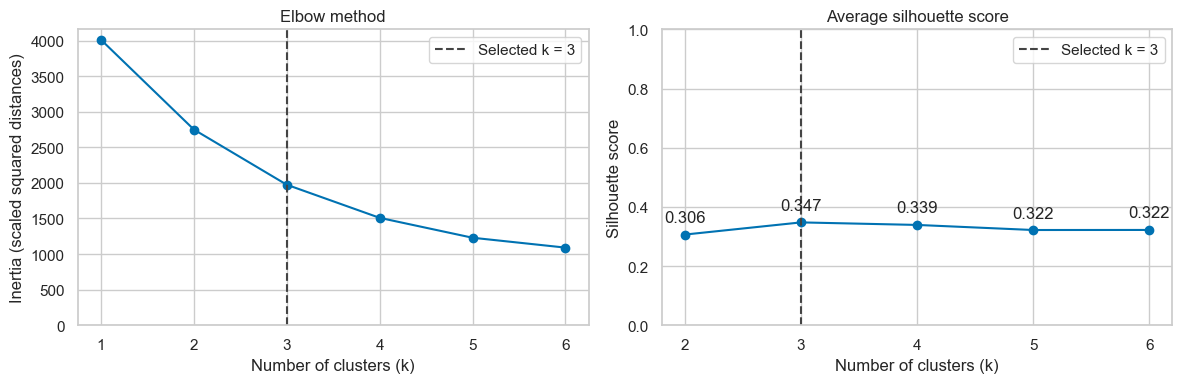

Selected k: 3; silhouette score: 0.347


In [4]:
best_k = int(results.loc[results["Silhouette"].idxmax(), "k"])
best_score = results["Silhouette"].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results["k"], results["Inertia"], marker="o", color="#0072B2")
axes[0].set(title="Elbow method", xlabel="Number of clusters (k)",
            ylabel="Inertia (scaled squared distances)", xticks=range(1, 7), ylim=(0, None))

tested = results[results["k"] >= 2]
axes[1].plot(tested["k"], tested["Silhouette"], marker="o", color="#0072B2")
axes[1].set(title="Average silhouette score", xlabel="Number of clusters (k)",
            ylabel="Silhouette score", xticks=range(2, 7), ylim=(0, 1))
for k, score in zip(tested["k"], tested["Silhouette"]):
    axes[1].annotate(f"{score:.3f}", (k, score), xytext=(0, 9),
                     textcoords="offset points", ha="center")

for ax in axes:
    ax.axvline(best_k, color="#444444", linestyle="--", label=f"Selected k = {best_k}")
    ax.legend()

plt.tight_layout()
plt.show()
print(f"Selected k: {best_k}; silhouette score: {best_score:.3f}")

Choosing k

**k = 3 has the highest silhouette score: 0.347.** The score falls to 0.339 at k = 4 and stays lower for k = 5 and 6.

Inertia decreases from about 2,749 at k = 2 to 1,974 at k = 3, then to 1,509 at k = 4. The improvements get smaller as more clusters are added. The elbow is gradual, around 3-4 clusters, rather than a sharp single answer. Together with the silhouette results, this supports choosing 3.

The score is well below 1, so these groups are not completely separated. This is the best result among the settings tested for these features, not proof of three natural types of people.

Cluster centres in original units

A centroid is the average position of the records in a cluster. We convert the centres back to years, BMI and dollars so they are easy to interpret.

Cluster numbers are just labels. We number the groups from lowest to highest average charges.

In [5]:
best_model = models[best_k]
centroids = pd.DataFrame(
    scaler.inverse_transform(best_model.cluster_centers_), columns=features
)

order = centroids["charges"].sort_values().index
cluster_names = {old: new for new, old in enumerate(order, start=1)}

clustered = df.copy()
clustered["cluster"] = pd.Series(best_model.labels_, index=df.index).map(cluster_names)

centroids = centroids.loc[order].copy()
centroids.index = range(1, best_k + 1)
centroids.index.name = "Cluster"

display(centroids.rename(columns={
    "age": "Mean age (years)", "bmi": "Mean BMI", "charges": "Mean charges ($)"
}).round(2))

,Mean age (years),Mean BMI,Mean charges ($)
Cluster,,,
1,27.34,29.01,6433.01
2,51.63,31.10,12774.81
3,39.76,35.28,40581.69


Plot the clusters

Each point is one record. Large X markers show the centroids. These are three two-dimensional views of the same clustering, which was fitted using all three features together. Points may overlap in a two-dimensional view even when they differ on the third feature.

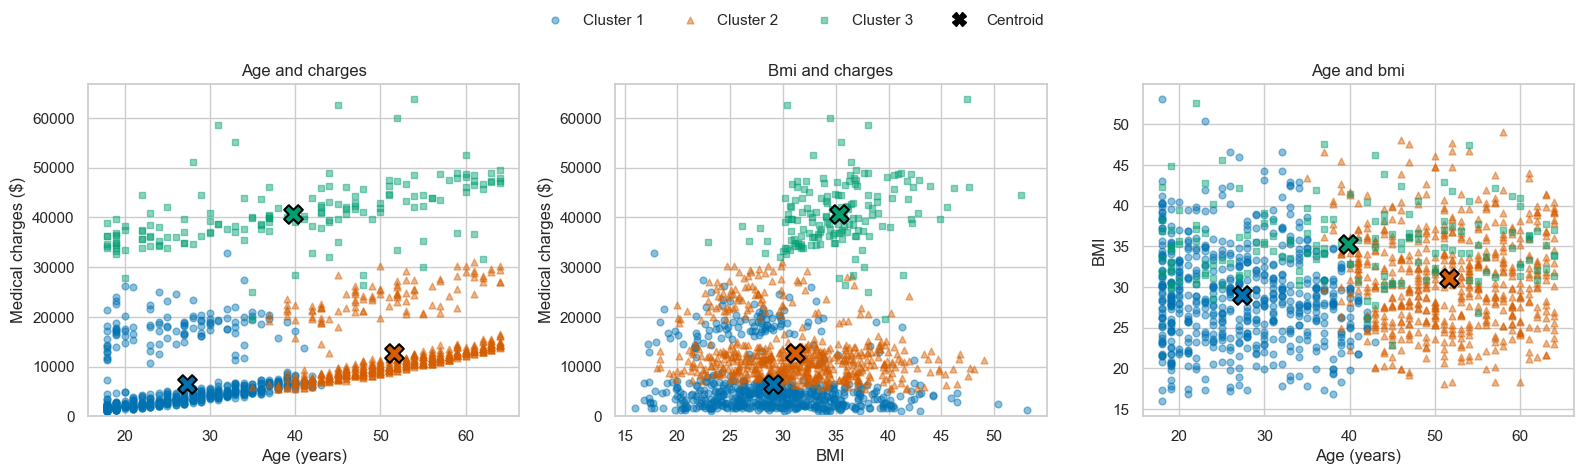

In [6]:
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]
markers = ["o", "^", "s", "D", "v", "P"]
pairs = [("age", "charges"), ("bmi", "charges"), ("age", "bmi")]
axis_labels = {"age": "Age (years)", "bmi": "BMI", "charges": "Medical charges ($)"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

for ax, (x, y) in zip(axes, pairs):
    for cluster in centroids.index:
        group = clustered[clustered["cluster"] == cluster]
        ax.scatter(group[x], group[y], s=24, alpha=0.45,
                   color=colors[cluster - 1], marker=markers[cluster - 1],
                   label=f"Cluster {cluster}")
        ax.scatter(centroids.loc[cluster, x], centroids.loc[cluster, y],
                   s=180, marker="X", color=colors[cluster - 1],
                   edgecolor="black", linewidth=1.5, zorder=5)
    ax.set(xlabel=axis_labels[x], ylabel=axis_labels[y],
           title=f"{x.capitalize()} and {y}")
    if y == "charges":
        ax.set_ylim(bottom=0)
        ax.ticklabel_format(style="plain", axis="y")

handles, labels = axes[0].get_legend_handles_labels()
handles.append(plt.Line2D([], [], marker="X", color="black", linestyle="None", markersize=10))
labels.append("Centroid")
fig.legend(handles, labels, loc="upper center", ncol=best_k + 1, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

Describe the groups

The table adds cluster sizes, median charges and the percentage of smokers. The silhouette mean for each group helps show which clusters are more distinct. Smoking status was not used to form the clusters.

In [7]:
profile_data = clustered.copy()
profile_data["is_smoker"] = profile_data["smoker"].eq("yes")
profile_data["silhouette"] = silhouette_samples(X_scaled, best_model.labels_)

profile = profile_data.groupby("cluster").agg(
    Records=("age", "size"),
    Median_charges=("charges", "median"),
    Smokers_percent=("is_smoker", lambda values: values.mean() * 100),
    Mean_silhouette=("silhouette", "mean")
)
profile.insert(1, "Share_percent", profile["Records"] / len(df) * 100)
display(profile.rename(columns={
    "Share_percent": "Share (%)", "Median_charges": "Median charges ($)",
    "Smokers_percent": "Smokers (%)", "Mean_silhouette": "Mean silhouette"
}).round(3))

,Records,Share (%),Median charges ($),Smokers (%),Mean silhouette
cluster,,,,,
1,604,45.176,4433.652,10.927,0.348
2,571,42.708,11163.568,10.333,0.330
3,162,12.117,39854.112,91.975,0.409


What the clusters show

- **Cluster 1:** 604 records. A younger group, with average age 27.3, BMI 29.0 and charges of about $6,433.
- **Cluster 2:** 571 records. An older group, with average age 51.6, BMI 31.1 and charges of about $12,775.
- **Cluster 3:** 162 records. The highest-cost group, with average age 39.8, BMI 35.3 and charges of about $40,582.

About 92% of Cluster 3 are smokers, compared with about 10-11% in the other groups. This describes an association in these records; it does not establish a cause.

The first two groups overlap in BMI and charges and differ mainly in age. The third has much higher charges on average. These are group averages, so individual records can differ considerably. The scatterplots show that the boundaries are not perfectly clear.

Cluster sizes and smoking status

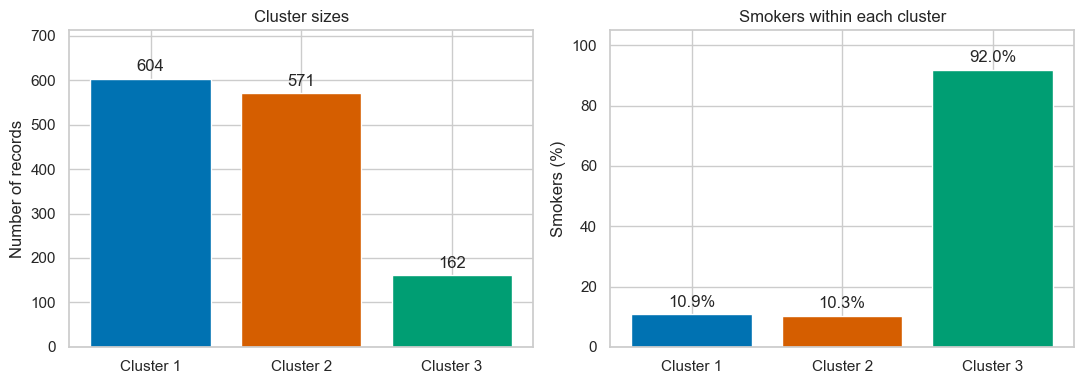

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cluster_labels = [f"Cluster {i}" for i in profile.index]

bars = axes[0].bar(cluster_labels, profile["Records"], color=colors[:best_k])
axes[0].bar_label(bars, padding=3)
axes[0].set(title="Cluster sizes", ylabel="Number of records",
            ylim=(0, profile["Records"].max() * 1.18))

bars = axes[1].bar(cluster_labels, profile["Smokers_percent"], color=colors[:best_k])
axes[1].bar_label(bars, labels=[f"{v:.1f}%" for v in profile["Smokers_percent"]], padding=3)
axes[1].set(title="Smokers within each cluster", ylabel="Smokers (%)", ylim=(0, 105))

plt.tight_layout()
plt.show()

Save the clustered data

`insurance_clustered.csv` contains the cleaned data in its original units plus the cluster number. It can be used later without running K-means again. The original, cleaned and preprocessed files remain unchanged.

In [9]:
clustered.to_csv("insurance_clustered.csv", index=False)
print("Saved insurance_clustered.csv:", clustered.shape)
display(clustered[["age", "bmi", "charges", "smoker", "cluster"]].head())

Saved insurance_clustered.csv: (1337, 10)


,age,bmi,charges,smoker,cluster
0,19,27.900,16884.92400,yes,1
1,18,33.770,1725.55230,no,1
2,28,33.000,4449.46200,no,1
3,33,22.705,21984.47061,no,1
4,32,28.880,3866.85520,no,1


Conclusion

We tested five K-means clusterings and selected **k = 3** using the highest silhouette score and the elbow curve. The groups describe younger records with lower average charges, older records with intermediate average charges, and a smaller group with much higher average charges.

The silhouette score of **0.347** indicates that the grouping has overlap. K-means always produces the requested number of groups, and its centres can be influenced by extreme values. These results depend on the selected features and scaling; they describe this dataset rather than confirmed real-world categories.